In [2]:
%load_ext autoreload
%autoreload 2
from imports import *


2025-04-29 10:37:16,911 - INFO - Common imports loading...


Executing common imports from imports.py...


In [3]:
oms = np.array([0.288775, 0.374240, 0.342157, 0.320652, 0.212092, 0.252952])
sig8s = np.array([0.868324, 0.803384, 0.607220, 0.788544, 0.698398])

hfid = 0.6898
w0fid = -1

In [4]:
theta1_arcmin = 15.0  # Use a descriptive name
R_pixels = int(theta1_arcmin / 0.5) #0.5 arcmin/pixel resolution
print(f"Filter radius in pixels: {R_pixels}")

snr = np.linspace(-6, 6, 300) # Define SNR range for output interpolation

# Source redshift - can be single value or list depending on analysis needs
zs_source = 1.852 #1.134 

# Path to n(z) file for the relevant bin
nz_file = "/feynman/work/dap/lcs/vt272285/LDT_2cell_l1_norm_recheck/nz_arrays_bin5.npy" 

# Parameters for calculations
kmin_pk = -4 # kmin for power spectrum calculation
kmax_pk = 10  # kmax for power spectrum calculation 
n_lensing_planes = 7 # Number of lensing planes

# --- Main Loop ---
data = {}
filter_type = 'tophat'
# --- Plotting Setup ---
fig, axs = plt.subplots(1, 2, figsize=(25, 15), dpi=100, gridspec_kw={'width_ratios': [2, 1]})
for cosmo_index_to_run in range(0,1):
    print(f"--- Running for Cosmology Index: {cosmo_index_to_run} ---")

    # --- Theoretical Prediction ---
    # 1. Get Cosmology Parameters
    h = hfid 
    Ob = 0.0473
    Om = oms[cosmo_index_to_run]
    Oc = Om - Ob
    sig8 = sig8s[cosmo_index_to_run] 
    w0 = w0fid 
    wa = 0 # 
    # Other fixed parameters
    H0 = 100.0 * h 
    ns = 0.963
    mnu = 0.0

    print("Cosmological Parameters:")
    print(f"  h={h:.4f}, Om={Om:.4f}, Oc={Oc:.4f}, Ob={Ob:.4f}, sigma8={sig8:.4f}, w0={w0:.4f}, wa={wa:.4f}")
    print(" ")
    
    # --- Data Storage ---
    l1_prediction_list = []
    sigmasq_prediction_list = []
    l1_simulation_list = []
    l1_simulation_errorbars_list = []
    simulation_pdf_list = []
    for times in range(10):
        # 2. Initialize Cosmology
        print("Initializing Cosmology...for iteration ", times)
        cosmo = Cosmology_function(
            h=h, H0=H0, Ob=Ob, Oc=Oc, mnu=mnu, ns=ns, zs=zs_source, 
            w=w0, wa=wa, kmin=kmin_pk, kmax=kmax_pk, nz_file=nz_file, sigma8=sig8)

        # 3. Calculate Geometric Quantities (Plane distances, weights)
        print("Calculating lensing geometry...")
        chi_source = cosmo.get_chi(zs_source)
        chis = np.linspace(0.3, chi_source - 5, n_lensing_planes) # Setup lensing planes
        dchis = np.ones(len(chis)) * (chis[1] - chis[0]) / 2 # Differential comoving distances
        dchis[1:-1] *= 2.

        if nz_file is not None:
            z_array, lensing_weight = cosmo.get_lensing_weight_array_nz(chis)
        else:
            z_array, lensing_weight = cosmo.get_lensing_weight_array(chis, chi_source) 

        print(f"  Source Redshift: {zs_source}, Comoving Distance: {chi_source:.2f} Mpc/h")
        print(f"  Number of lensing planes: {n_lensing_planes}")

        # Determine appropriate redshift range based on z_array or zs_source
        max_crit_z = min(zs_source * 0.5, np.max(z_array)) if len(z_array)>0 else zs_source*0.95 # Avoid edge
        crit_point_z = np.linspace(0.02, zs_source * 0.45, 5) 

        # 4. Initialize Variance (this will compute P(k) internally)
        print("Initializing Variance and P(k)...")
        variance = Variance(
            cosmo=cosmo, 
            z_values=z_array, # Pass the plane redshifts for P(k) calculation range
            z_values_critical = crit_point_z,
            filter_type = filter_type,
            variability=True, 
            delta_A0=.7 # Default value from original compute_pk_with_cv
        )

        # 5. Initialize VariablesGenerator (this calculates sigmasq_map)
        print("Initializing VariablesGenerator...")
        variables = VariablesGenerator(
            cosmo=cosmo, 
            variance=variance, 
            zs=zs_source, 
            theta1=theta1_arcmin, 
            nz_file=nz_file, 
            nplanes=n_lensing_planes,
            chis=chis, 
            dchis=dchis, 
            z_array=z_array, 
            lensing_weight=lensing_weight
        )

        variables.recal_value = 1.0 
        print(f"Theoretical Map Variance (sigmasq_map): {variables.sigmasq_map:.4g}")
        print(f"Recalibration Value Set To: {variables.recal_value}") 

        if cosmo_index_to_run == 0:
            variables.lambdas = np.linspace(-120, 250, 30) 
        elif cosmo_index_to_run == 2:
            variables.lambdas = np.linspace(-120, 300, 30)
        elif cosmo_index_to_run == 3:
            variables.lambdas = np.linspace(-150, 200, 30)
        else:
            variables.lambdas = np.linspace(-100, 270, 30)
        
        computed_PDF = computePDF(variables, plot_scgf=False) # Pass the updated variables object
        pdf_values, kappa_values = computed_PDF.pdf_values, computed_PDF.kappa_values

        # 8. Calculate Predicted L1 norm
        print("Calculating predicted L1 norm...")
        # pdf_spline = CubicSpline(kappa_values, pdf_values) 
        l1_pred_values = get_l1_from_pdf(pdf_values, kappa_values)

        # Interpolate L1 onto the common SNR grid
        pred_stdev = np.sqrt(variables.sigmasq_map)
        if pred_stdev > 1e-12:
            kappa_over_sigma_pred = kappa_values / pred_stdev
            l1_pred_spline = CubicSpline(kappa_over_sigma_pred, l1_pred_values, extrapolate=False)
            l1_pred_on_snr = l1_pred_spline(snr)
        else:
            l1_pred_on_snr = np.nan

        # Store predictions
        sigmasq_prediction_list.append(variables.sigmasq_map)
        l1_prediction_list.append(l1_pred_on_snr)
        # Prediction L1
        
        # Plotting L1 comparison
        colour = list(np.random.choice(range(256), size=3) / 255) # Random color for this run
        plot_scale_factor = 1.0 # 
        x_axis_vals = snr #* pred_stdev # Plot against kappa = snr * sigma_pred
        axs[0].plot(x_axis_vals, l1_pred_on_snr * plot_scale_factor, alpha=0.6, c='cornflowerblue') 
        axs[1].plot(kappa_values, pdf_values, color=colour, alpha=0.5) # Plot the PDF for this cosmology
        # Calculate moments from predicted PDF
        pred_stats = get_moments(kappa_values, pdf_values)
        pred_mean, pred_var, pred_skew, pred_kurt, pred_norm = pred_stats
        print(f"Prediction PDF Moments: Mean={pred_mean:.4g}, Variance={pred_var:.4g}, Skewness={pred_skew:.4g}, Kurtosis={pred_kurt:.4g}")

        # --- Comparison and Plotting ---
        print("\n--- Comparison ---")
        comparison_data = {
            "Metric": ["Mean", "Variance", "Skewness", "Kurtosis", "Norm"],
            "Prediction PDF": [f"{v:.4g}" for v in pred_stats],
            # "Simulation Avg PDF": [f"{v:.4g}" for v in sim_stats],
        }
        df_comp = pd.DataFrame(comparison_data)
        print(df_comp)
        print("-----------------\n")
    
    l1_prediction_list = np.array(l1_prediction_list)
    avg_pred_l1 = np.mean(l1_prediction_list, axis=0)
    std_pred_l1 = np.std(l1_prediction_list, axis=0)
    
    data[f"index{cosmo_index_to_run}"] = {
        "cosmology_index": cosmo_index_to_run,
        "snr": snr,
        "l1_prediction": l1_prediction_list,
        "sigmasq_prediction": variables.sigmasq_map,
        "Om": Om,
        "h": h,
        "w0": w0,
        "sig8": sig8,
    }
    
    # Define two distinct colors
    colour_pred = 'royalblue' #np.random.rand(3)  # Random color for prediction
    
    axs[0].errorbar(
        x_axis_vals[::3],  # Subsample for clarity
        avg_pred_l1[::3] * plot_scale_factor, 
        yerr=std_pred_l1[::3] * plot_scale_factor, 
        ls="--", marker="s", color=colour_pred, alpha=0.9, ecolor=colour_pred, capsize=3, 
        label=f"Prediction Avg (Cosmo {cosmo_index_to_run})"
    ) 

    # Add cosmology label to the second axes panel
    # axs[1].scatter(1, 25 - cosmo_index_to_run, color=colour_pred) # Adjust y-positioning as needed
    # axs[1].annotate(f"Cosmo {cosmo_index_to_run}", (1, 25 - cosmo_index_to_run), xytext=(5, 0), textcoords='offset points', va='center')
    

    # --- Final Plot Formatting ---
    axs[0].hlines(0, np.min(x_axis_vals), np.max(x_axis_vals), color='gray', ls='--')
    axs[0].axhspan(-0.05 * plot_scale_factor, 0.05 * plot_scale_factor, color='gray', alpha=0.2) # Adjust span based on plot scale
    axs[0].set_xlabel(r'SNR = $\kappa / \sigma_{pred}$', size=14) 
    # axs[0].set_xlabel(r'$\kappa = \mathrm{SNR} \times \sigma_{pred}$', size=14)
    axs[0].set_ylabel(r'$\ell_1(\kappa)$ Scaled', size=14) # Adjust label if scale factor changes
    # Set xlim based on plotted range, e.g., +/- 3 sigma
    xlim_range = 5 * pred_stdev 
    axs[0].set_xlim(-6, 6) 
    axs[1].set_xlim(-0.025,0.025)
    
    

# ylim can be set dynamically or fixed
# axs[0].set_ylim(-0.1 * plot_scale_factor, np.nanmax(l1_pred_on_snr * plot_scale_factor) * 1.1) 
axs[0].grid(True, which='both', axis='both')
axs[0].legend() # Add legend to the main plot
axs[1].grid(True, which='both', axis='both')
axs[1].legend()
plt.tight_layout()
plt.show()


plt.figure()
plt.imshow(np.cov(l1_prediction_list, rowvar=False), cmap='viridis', origin='lower')
plt.colorbar()
plt.show()

Filter radius in pixels: 30
--- Running for Cosmology Index: 0 ---
Cosmological Parameters:
  h=0.6898, Om=0.2888, Oc=0.2415, Ob=0.0473, sigma8=0.8683, w0=-1.0000, wa=0.0000
 
Initializing Cosmology...for iteration  0
the min and max values of k are:  0.0001 10000000000.0 and length is:  50
Calculating lensing geometry...
  Source Redshift: 1.852, Comoving Distance: 3503.46 Mpc/h
  Number of lensing planes: 7
Initializing Variance and P(k)...
Variability is ON
Effective volume = 5.97e+07 (Mpc/h)^3
halo model calculator initialized


/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/pk2d.py:285: RuntimeWarning: divide by zero encountered in log
  lk_use = np.log(k_use)
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1021: RuntimeWarning: divide by zero encountered in divide
  f2 = 5./7. - 0.5 * (1 + kk ** 2 / kr2) * (1 + kp / kk * cth) + \
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1021: RuntimeWarning: invalid value encountered in multiply
  f2 = 5./7. - 0.5 * (1 + kk ** 2 / kr2) * (1 + kp / kk * cth) + \
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1022: RuntimeWarning: divide by zero encountered in divide
  2/7. * kk ** 2 / kr2 * (1 + kp / kk * cth)**2
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1022: RuntimeWarning: invalid value encountered in multiply
  2

Variance module initialized.e final z: 0.83
Initializing VariablesGenerator...
Calculating sigmasq_map...
the shapes are:  (7,) (7,)
VariablesGenerator Initialized:
  Source Redshift (zs): 1.852
  Angular Scale (theta1): 15.0 arcmin
  Number of Planes: 7
  Using n(z) file: True
  Calculated Map Variance (sigmasq_map): 2.2587309817738646e-05
Theoretical Map Variance (sigmasq_map): 2.259e-05
Recalibration Value Set To: 1.0
2.258713479058717e-05428571 %%
Calculating predicted L1 norm...
Prediction PDF Moments: Mean=-1.022e-07, Variance=2.257e-05, Skewness=-60.07, Kurtosis=0.4941

--- Comparison ---
     Metric Prediction PDF
0      Mean     -1.022e-07
1  Variance      2.257e-05
2  Skewness         -60.07
3  Kurtosis         0.4941
4      Norm              1
-----------------

Initializing Cosmology...for iteration  1
the min and max values of k are:  0.0001 10000000000.0 and length is:  50
Calculating lensing geometry...
  Source Redshift: 1.852, Comoving Distance: 3503.46 Mpc/h
  Number 

/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/pk2d.py:285: RuntimeWarning: divide by zero encountered in log
  lk_use = np.log(k_use)
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1021: RuntimeWarning: divide by zero encountered in divide
  f2 = 5./7. - 0.5 * (1 + kk ** 2 / kr2) * (1 + kp / kk * cth) + \
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1021: RuntimeWarning: invalid value encountered in multiply
  f2 = 5./7. - 0.5 * (1 + kk ** 2 / kr2) * (1 + kp / kk * cth) + \
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1022: RuntimeWarning: divide by zero encountered in divide
  2/7. * kk ** 2 / kr2 * (1 + kp / kk * cth)**2
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1022: RuntimeWarning: invalid value encountered in multiply
  2

Variance module initialized.e final z: 0.83
Initializing VariablesGenerator...
Calculating sigmasq_map...
the shapes are:  (7,) (7,)
VariablesGenerator Initialized:
  Source Redshift (zs): 1.852
  Angular Scale (theta1): 15.0 arcmin
  Number of Planes: 7
  Using n(z) file: True
  Calculated Map Variance (sigmasq_map): 2.2054931249575774e-05
Theoretical Map Variance (sigmasq_map): 2.205e-05
Recalibration Value Set To: 1.0
2.2054948097319643e-0528571 %%
Calculating predicted L1 norm...
Prediction PDF Moments: Mean=-5.774e-08, Variance=2.205e-05, Skewness=-37.23, Kurtosis=0.4885

--- Comparison ---
     Metric Prediction PDF
0      Mean     -5.774e-08
1  Variance      2.205e-05
2  Skewness         -37.23
3  Kurtosis         0.4885
4      Norm              1
-----------------

Initializing Cosmology...for iteration  2
the min and max values of k are:  0.0001 10000000000.0 and length is:  50
Calculating lensing geometry...
  Source Redshift: 1.852, Comoving Distance: 3503.46 Mpc/h
  Number 

/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/pk2d.py:285: RuntimeWarning: divide by zero encountered in log
  lk_use = np.log(k_use)
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1021: RuntimeWarning: divide by zero encountered in divide
  f2 = 5./7. - 0.5 * (1 + kk ** 2 / kr2) * (1 + kp / kk * cth) + \
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1021: RuntimeWarning: invalid value encountered in multiply
  f2 = 5./7. - 0.5 * (1 + kk ** 2 / kr2) * (1 + kp / kk * cth) + \
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1022: RuntimeWarning: divide by zero encountered in divide
  2/7. * kk ** 2 / kr2 * (1 + kp / kk * cth)**2
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1022: RuntimeWarning: invalid value encountered in multiply
  2

Variance module initialized.e final z: 0.83
Initializing VariablesGenerator...
Calculating sigmasq_map...
the shapes are:  (7,) (7,)
VariablesGenerator Initialized:
  Source Redshift (zs): 1.852
  Angular Scale (theta1): 15.0 arcmin
  Number of Planes: 7
  Using n(z) file: True
  Calculated Map Variance (sigmasq_map): 2.2553981569496323e-05
Theoretical Map Variance (sigmasq_map): 2.255e-05
Recalibration Value Set To: 1.0
2.255391616485682e-05428571 %%
Calculating predicted L1 norm...
Prediction PDF Moments: Mean=-4.673e-08, Variance=2.255e-05, Skewness=-44.22, Kurtosis=0.3301

--- Comparison ---
     Metric Prediction PDF
0      Mean     -4.673e-08
1  Variance      2.255e-05
2  Skewness         -44.22
3  Kurtosis         0.3301
4      Norm              1
-----------------

Initializing Cosmology...for iteration  3
the min and max values of k are:  0.0001 10000000000.0 and length is:  50
Calculating lensing geometry...
  Source Redshift: 1.852, Comoving Distance: 3503.46 Mpc/h
  Number 

/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/pk2d.py:285: RuntimeWarning: divide by zero encountered in log
  lk_use = np.log(k_use)
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1021: RuntimeWarning: divide by zero encountered in divide
  f2 = 5./7. - 0.5 * (1 + kk ** 2 / kr2) * (1 + kp / kk * cth) + \
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1021: RuntimeWarning: invalid value encountered in multiply
  f2 = 5./7. - 0.5 * (1 + kk ** 2 / kr2) * (1 + kp / kk * cth) + \
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1022: RuntimeWarning: divide by zero encountered in divide
  2/7. * kk ** 2 / kr2 * (1 + kp / kk * cth)**2
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1022: RuntimeWarning: invalid value encountered in multiply
  2

Variance module initialized.e final z: 0.83
Initializing VariablesGenerator...
Calculating sigmasq_map...
the shapes are:  (7,) (7,)
VariablesGenerator Initialized:
  Source Redshift (zs): 1.852
  Angular Scale (theta1): 15.0 arcmin
  Number of Planes: 7
  Using n(z) file: True
  Calculated Map Variance (sigmasq_map): 2.263891503428511e-05
Theoretical Map Variance (sigmasq_map): 2.264e-05
Recalibration Value Set To: 1.0
2.2638482186504374e-0528571 %%
Calculating predicted L1 norm...
Prediction PDF Moments: Mean=1.019e-08, Variance=2.264e-05, Skewness=-68.03, Kurtosis=0.6064

--- Comparison ---
     Metric Prediction PDF
0      Mean      1.019e-08
1  Variance      2.264e-05
2  Skewness         -68.03
3  Kurtosis         0.6064
4      Norm              1
-----------------

Initializing Cosmology...for iteration  4
the min and max values of k are:  0.0001 10000000000.0 and length is:  50
Calculating lensing geometry...
  Source Redshift: 1.852, Comoving Distance: 3503.46 Mpc/h
  Number of

/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/pk2d.py:285: RuntimeWarning: divide by zero encountered in log
  lk_use = np.log(k_use)
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1021: RuntimeWarning: divide by zero encountered in divide
  f2 = 5./7. - 0.5 * (1 + kk ** 2 / kr2) * (1 + kp / kk * cth) + \
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1021: RuntimeWarning: invalid value encountered in multiply
  f2 = 5./7. - 0.5 * (1 + kk ** 2 / kr2) * (1 + kp / kk * cth) + \
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1022: RuntimeWarning: divide by zero encountered in divide
  2/7. * kk ** 2 / kr2 * (1 + kp / kk * cth)**2
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1022: RuntimeWarning: invalid value encountered in multiply
  2

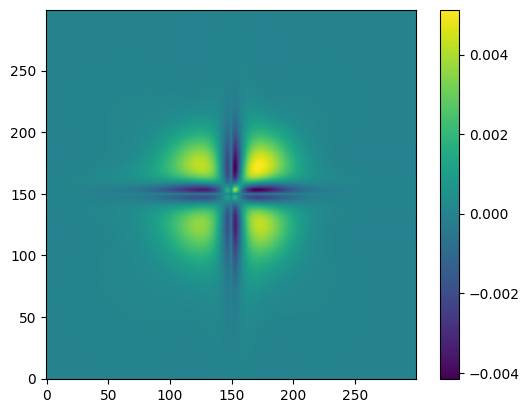

In [11]:
data

{'index1': {'cosmology_index': 1,
  'snr': array([-7.        , -6.92964824, -6.85929648, -6.78894472, -6.71859296,
         -6.64824121, -6.57788945, -6.50753769, -6.43718593, -6.36683417,
         -6.29648241, -6.22613065, -6.15577889, -6.08542714, -6.01507538,
         -5.94472362, -5.87437186, -5.8040201 , -5.73366834, -5.66331658,
         -5.59296482, -5.52261307, -5.45226131, -5.38190955, -5.31155779,
         -5.24120603, -5.17085427, -5.10050251, -5.03015075, -4.95979899,
         -4.88944724, -4.81909548, -4.74874372, -4.67839196, -4.6080402 ,
         -4.53768844, -4.46733668, -4.39698492, -4.32663317, -4.25628141,
         -4.18592965, -4.11557789, -4.04522613, -3.97487437, -3.90452261,
         -3.83417085, -3.7638191 , -3.69346734, -3.62311558, -3.55276382,
         -3.48241206, -3.4120603 , -3.34170854, -3.27135678, -3.20100503,
         -3.13065327, -3.06030151, -2.98994975, -2.91959799, -2.84924623,
         -2.77889447, -2.70854271, -2.63819095, -2.5678392 , -2.4974874